<a href="https://colab.research.google.com/github/RegistryHJ/pico-with-data-pi/blob/main/src/examples/ex25_environment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 환경 분석

### 라이브러리 임포트

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

### 데이터 불러오기

data_ai.csv - AI Lab 표본 데이터

In [2]:
# CSV 파일 경로 (data_ai.csv를 가상 드라이브에 업로드)
csv_ai = "./data_ai.csv"

# CSV 파일 읽어서 데이터프레임으로 변환
df_ai = pd.read_csv(csv_ai, names=["DateTime", "Temp", "Humid", "AQI", "CO2", "TVOC"])

# 데이터프레임의 선두 5개의 데이터 확인하기
df_ai.head()

,DateTime,Temp,Humid,AQI,CO2,TVOC
0,2024.10.8 14:18,23.38,72.24,1,400,16
1,2024.10.8 14:48,24.10,67.65,1,430,37
2,2024.10.8 15:18,24.11,67.77,1,411,29
3,2024.10.8 15:48,24.43,66.68,1,480,61
4,2024.10.8 16:18,24.68,66.45,2,567,110


data_multi.csv - 멀티미디어실 표본 데이터

In [3]:
# CSV 파일 경로 (data_multi.csv를 가상 드라이브에 업로드)
csv_multi = "./data_multi.csv"

# CSV 파일 읽어서 데이터프레임으로 변환
df_multi = pd.read_csv(csv_multi, names=["DateTime", "Temp", "Humid", "AQI", "CO2", "TVOC"])

# 데이터프레임의 선두 5개의 데이터 확인하기
df_multi.head()

,DateTime,Temp,Humid,AQI,CO2,TVOC
0,2024.10.8 14:50,23.96,52.17,2,604,135
1,2024.10.8 14:50,23.96,52.11,2,608,138
2,2024.10.8 15:20,23.52,53.62,1,400,8
3,2024.10.8 15:50,23.62,53.47,1,411,29
4,2024.10.8 16:20,25.01,50.70,2,541,95


### 1. 데이터 기본 통계 정보 확인

<table border="1" cellpadding="5" cellspacing="0">
  <thead>
    <tr>
      <th><strong>항목</strong></th>
      <th><strong>설명</strong></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>count</strong></td>
      <td>해당 열(변수)의 데이터 개수(NaN(결측값)은 제외)</td>
    </tr>
    <tr>
      <td><strong>mean</strong></td>
      <td>평균값</td>
    </tr>
    <tr>
      <td><strong>std</strong></td>
      <td>표준편차</td>
    </tr>
    <tr>
      <td><strong>min</strong></td>
      <td>최솟값</td>
    </tr>
    <tr>
      <td><strong>25%</strong></td>
      <td>1사분위수; 하위 25%, 상위 75%</td>
    </tr>
    <tr>
      <td><strong>50%</strong></td>
      <td>2사분위수; 중앙값(median)</td>
    </tr>
    <tr>
      <td><strong>75%</strong></td>
      <td>3사분위수; 하위 75%, 상위 25%</td>
    </tr>
    <tr>
      <td><strong>max</strong></td>
      <td>최댓값</td>
    </tr>
  </tbody>
</table>

In [4]:
print(f"Ai Lab 기본 통계 정보:\n{df_ai.describe()}\n")
print(f"멀티미디어실 기본 통계 정보:\n{df_multi.describe()}")

Ai Lab 기본 통계 정보:
             Temp       Humid         AQI         CO2        TVOC
count  375.000000  375.000000  375.000000  375.000000  375.000000
mean    24.031040   66.863627    2.138667  635.341333  187.056000
std      0.685206    9.545583    0.647474  136.822852  139.831027
min     22.080000   43.710000    1.000000  400.000000   16.000000
25%     23.520000   61.230000    2.000000  517.000000   81.000000
50%     24.060000   65.240000    2.000000  623.000000  148.000000
75%     24.575000   68.775000    3.000000  744.500000  243.500000
max     26.340000   89.300000    4.000000  916.000000  670.000000

멀티미디어실 기본 통계 정보:
             Temp       Humid         AQI          CO2         TVOC
count  386.000000  386.000000  386.000000   386.000000   386.000000
mean    24.832720   51.443057    1.839378   569.642487   134.761658
std      0.683421    6.399250    0.636634   125.288702   195.208421
min     22.970000   34.320000    1.000000   400.000000     0.000000
25%     24.340000   47.790000  

### 2. 수치별 플롯을 만들어 비교하기

2.1 데이터 전처리

In [5]:
# 시간 형식 변환
df_ai["DateTime"] = pd.to_datetime(df_ai["DateTime"])
df_multi["DateTime"] = pd.to_datetime(df_multi["DateTime"])

# 일자 행 추출
df_ai["Date"] = df_ai["DateTime"].dt.date
df_multi["Date"] = df_multi["DateTime"].dt.date

2.2 온도(Temperature)

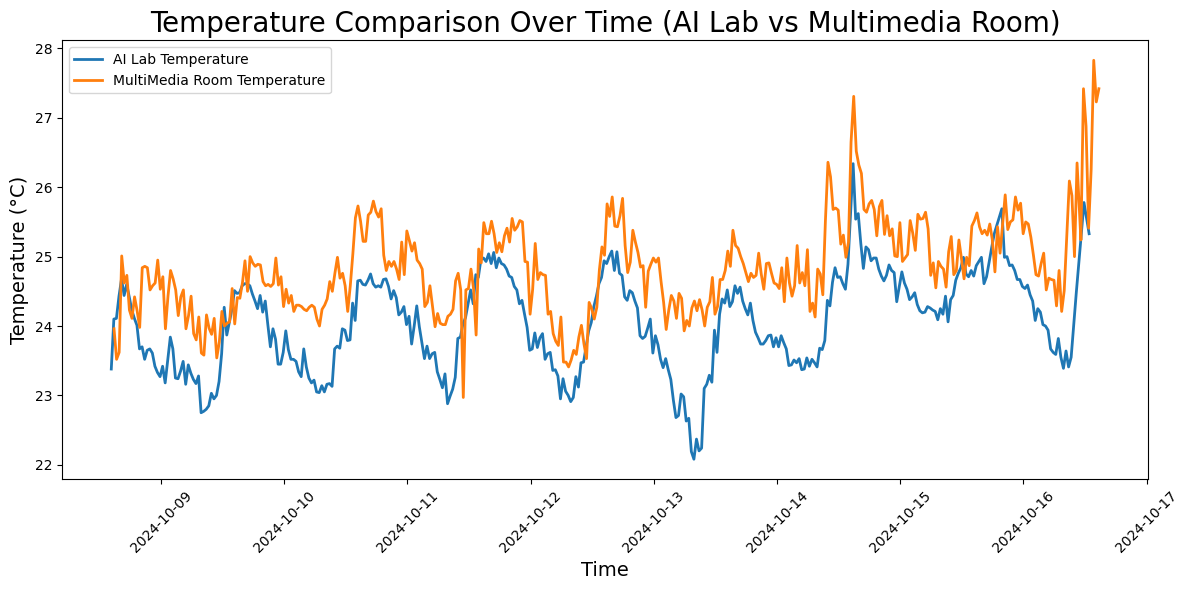

In [6]:
# 플롯 Figure 크기 지정
plt.figure(figsize=(12, 6))

# 플롯 데이터 표시 설정
plt.plot(df_ai["DateTime"], df_ai["Temp"], label="AI Lab Temperature", linewidth=2)
plt.plot(df_multi["DateTime"], df_multi["Temp"], label="MultiMedia Room Temperature", linewidth=2)

# 플롯 타이틀 설정
plt.title("Temperature Comparison Over Time (AI Lab vs Multimedia Room)", fontsize=20)

# 플롯의 X축, Y축 레이블 설정
plt.xlabel("Time", fontsize=14)
plt.ylabel("Temperature (°C)", fontsize=14)

# 플롯의 X축 눈금 레이블 45° 회전
plt.xticks(rotation=45)

# 플롯 레이아웃 최적화
plt.tight_layout()

# 플롯에 범례 표시
plt.legend()

# 플롯 출력
plt.show()

2.3 습도(Humidity)

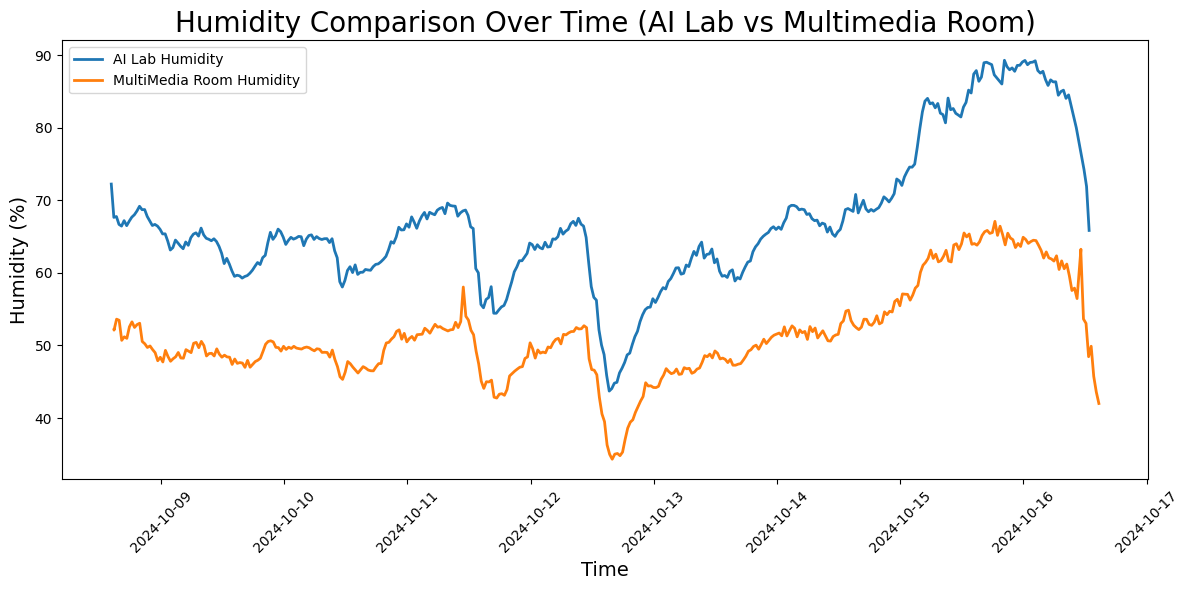

In [7]:
# 플롯 Figure 크기 지정
plt.figure(figsize=(12, 6))

# 플롯 데이터 표시 설정
plt.plot(df_ai["DateTime"], df_ai["Humid"], label="AI Lab Humidity", linewidth=2)
plt.plot(df_multi["DateTime"], df_multi["Humid"], label="MultiMedia Room Humidity", linewidth=2)

# 플롯 타이틀 설정
plt.title("Humidity Comparison Over Time (AI Lab vs Multimedia Room)", fontsize=20)

# 플롯의 X축, Y축 레이블 설정
plt.xlabel("Time", fontsize=14)
plt.ylabel("Humidity (%)", fontsize=14)

# 플롯의 X축 눈금 레이블 45° 회전
plt.xticks(rotation=45)

# 플롯 레이아웃 최적화
plt.tight_layout()

# 플롯에 범례 표시
plt.legend()

# 플롯 출력
plt.show()

2.4 AQI(Air Quality Index)

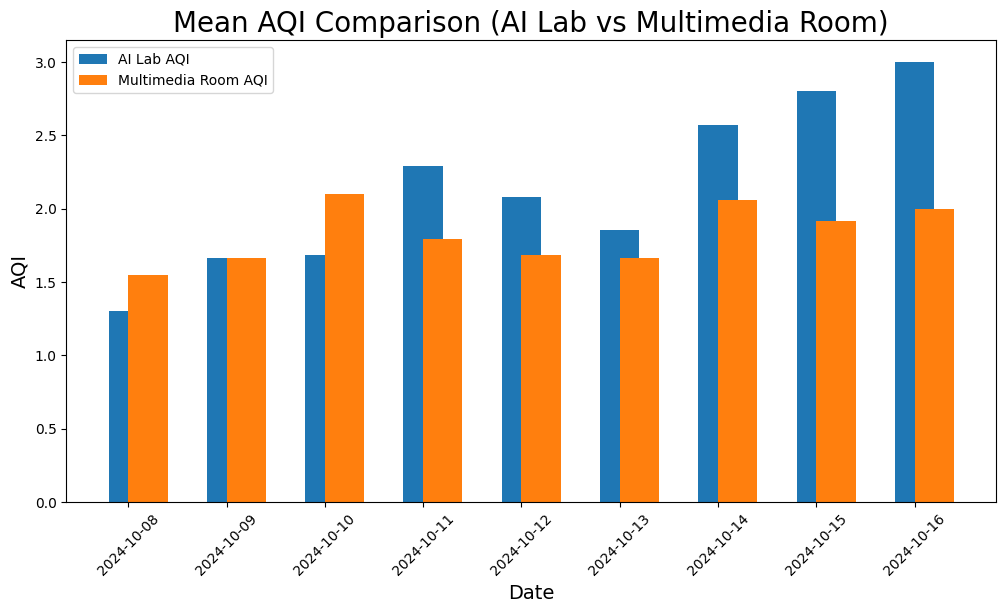

In [8]:
# 일자별 평균 AQI 산출
aqi_ai_mean= df_ai.groupby("Date")["AQI"].mean().reset_index()
aqi_multi_mean = df_multi.groupby("Date")["AQI"].mean().reset_index()

# 서브플롯 figure와 axes 객체 생성 (크기 지정)
fig, ax = plt.subplots(figsize=(12, 6))

# 서브플롯 막대 데이터 표시 설정
ax.bar(aqi_ai_mean["Date"], aqi_ai_mean["AQI"], width=0.4, label="AI Lab AQI", align="center")
ax.bar(aqi_multi_mean["Date"], aqi_multi_mean["AQI"], width=0.4, label="Multimedia Room AQI", align="edge")

# 서브플롯 타이틀 설정
ax.set_title("Mean AQI Comparison (AI Lab vs Multimedia Room)", fontsize=20)

# 서브플롯 X축, Y축 레이블 설정
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("AQI", fontsize=14)

# 플롯의 X축 눈금 레이블 45° 회전
plt.xticks(rotation=45)

# 서브플롯에 범례 표시
ax.legend()

2.5 CO2

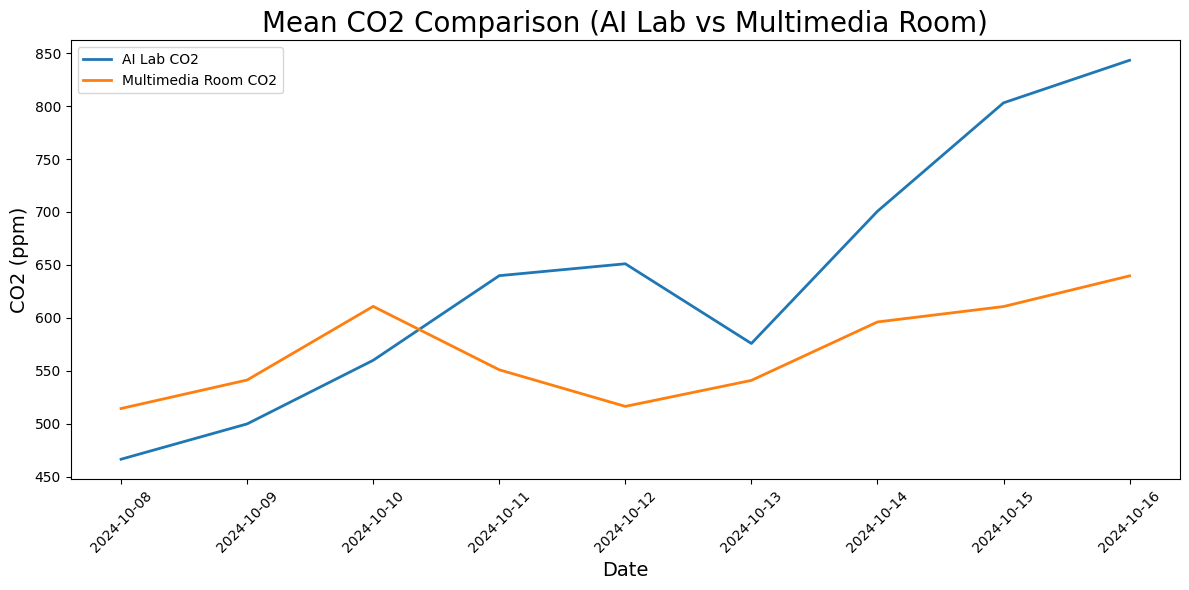

In [9]:
# 일자별 평균 CO2 산출
co2_ai_mean = df_ai.groupby("Date")["CO2"].mean().reset_index()
co2_multi_mean = df_multi.groupby("Date")["CO2"].mean().reset_index()

# 플롯 Figure 크기 지정
plt.figure(figsize=(12, 6))

# 플롯 데이터 표시 설정
plt.plot(co2_ai_mean["Date"], co2_ai_mean["CO2"], label="AI Lab CO2", linewidth=2)
plt.plot(co2_multi_mean["Date"], co2_multi_mean["CO2"], label="Multimedia Room CO2", linewidth=2)

# 플롯 타이틀 설정
plt.title("Mean CO2 Comparison (AI Lab vs Multimedia Room)", fontsize=20)

# 플롯의 X축, Y축 레이블 설정
plt.xlabel("Date", fontsize=14)
plt.ylabel("CO2 (ppm)", fontsize=14)

# 플롯의 X축 눈금 레이블 45° 회전
plt.xticks(rotation=45)

# 플롯 레이아웃 최적화
plt.tight_layout()

# 플롯에 범례 표시
plt.legend()

# 플롯 출력
plt.show()

2.6 TVOC

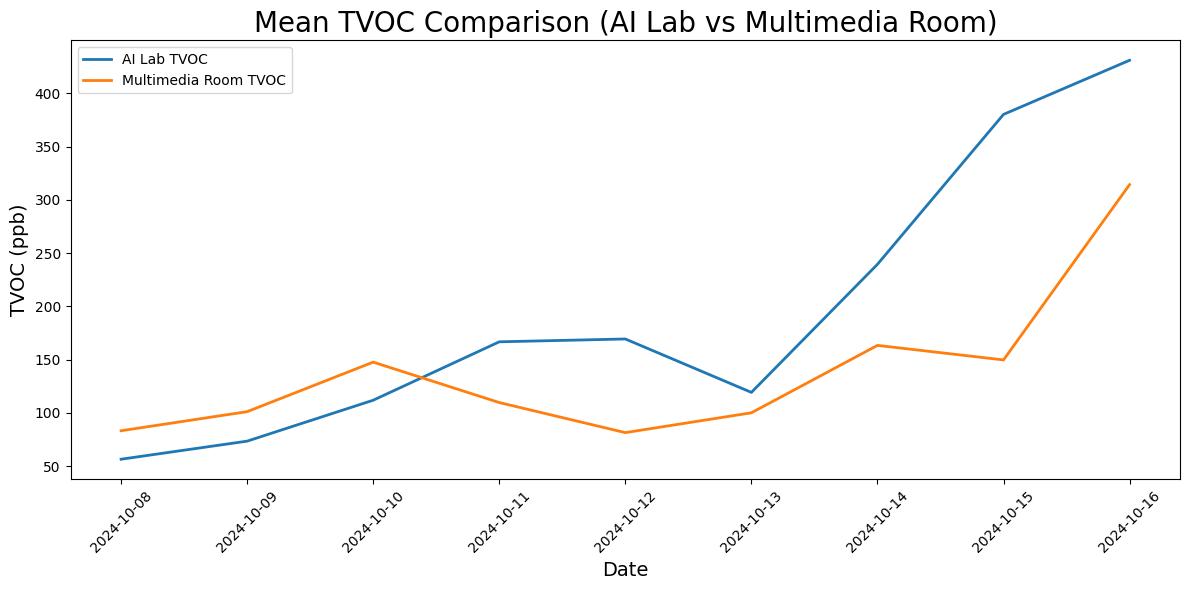

In [10]:
# 일자별 평균 TVOC 산출
tvoc_ai_mean = df_ai.groupby("Date")["TVOC"].mean().reset_index()
tvoc_multi_mean= df_multi.groupby("Date")["TVOC"].mean().reset_index()

# 플롯 Figure 크기 지정
plt.figure(figsize=(12, 6))

# 플롯 데이터 표시 설정
plt.plot(tvoc_ai_mean["Date"], tvoc_ai_mean["TVOC"], label="AI Lab TVOC", linewidth=2)
plt.plot(tvoc_multi_mean["Date"], tvoc_multi_mean["TVOC"], label="Multimedia Room TVOC", linewidth=2)

# 플롯 타이틀 설정
plt.title("Mean TVOC Comparison (AI Lab vs Multimedia Room)", fontsize=20)

# 플롯의 X축, Y축 레이블 설정
plt.xlabel("Date", fontsize=14)
plt.ylabel("TVOC (ppb)", fontsize=14)

# 플롯의 X축 눈금 레이블 45° 회전
plt.xticks(rotation=45)

# 플롯 레이아웃 최적화
plt.tight_layout()

# 플롯에 범례 표시
plt.legend()

# 플롯 출력
plt.show()